C:\Users\marc.maynou\AppData\Local\Temp\ipykernel_16048\9547996.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


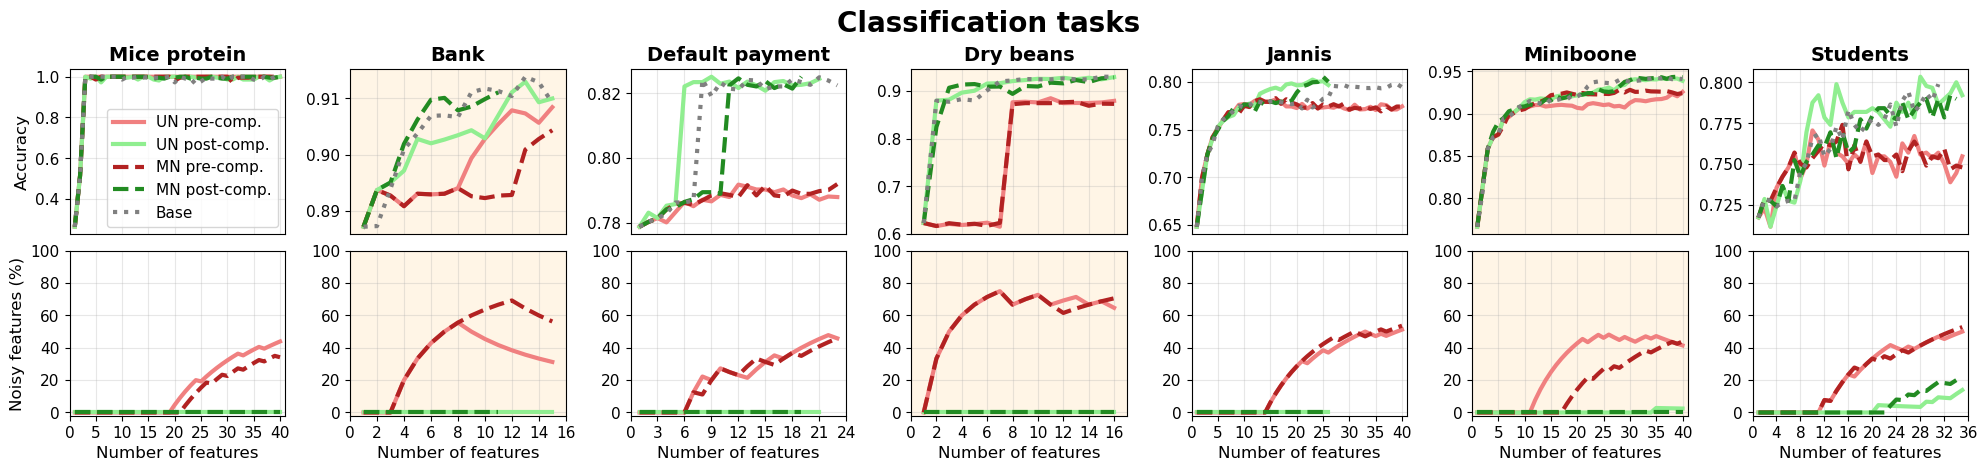

C:\Users\marc.maynou\AppData\Local\Temp\ipykernel_16048\9547996.py:210: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


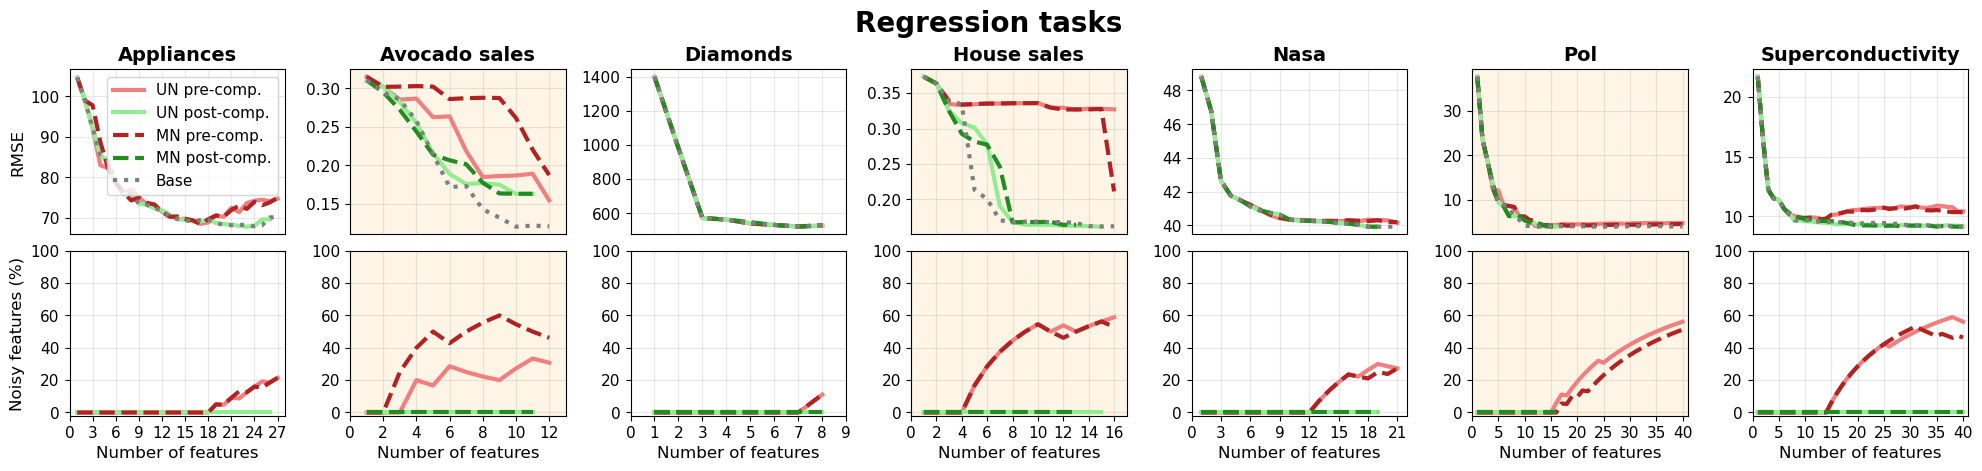

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.ticker import MaxNLocator

##### CONFIG

FILES = {
    "classification": "results_final_classification.csv",
    "regression": "results_final_regression.csv",
}

NOISY_PATTERNS = ["noise_", "_shuffled_", "spurious_"]

variants = {
    "noisy_1cf": {"suffix": "_un_dirty", "color": "lightcoral", "label": "UN pre-comp.", "linestyle": "-","marker": "o"},
    "cleaned_1cf": {"suffix": "_un_clean", "color": "lightgreen", "label": "UN post-comp.", "linestyle": "-","marker": "o"},
    "noisy_2cf": {"suffix": "_mn_dirty","color": "firebrick","label": "MN pre-comp.", "linestyle": "--","marker": "o"},
    "cleaned_2cf": {"suffix": "_mn_clean","color": "forestgreen","label": "MN post-comp.", "linestyle": "--","marker": "o"},
    "normal": {"suffix": "", "color": "grey", "label": "Base", "linestyle": ":","marker": "o"},
}

STYLE = {"title_size": 14, "label_size": 12, "tick_size": 11, "legend_size": 11, 
         "pair_hspace": 0.1, "group_hspace": -0.08, "fig_w": 3.5, "fig_h": 3, "pair_wspace": 0.3}

MAX_FEATURES_PER_BENCHMARK = {
    "bank": 15,
    "default_payment": 23,
    "jannis": 40, # 53
    "miniboone": 40, # 49
    "appliances": 27,
    "avocado_sales": 12,
    "diamonds": 8,
    "house_sales": 16,
    "nasa": 21,
    "pol": 40, # 47
    "superconductivity": 40, # 81
    "covertype": 12,
    "drive_diagnosis": 40, # 47
    "dry_beans": 16,
    "mice_protein": 40, # 80
    "pendigits": 16,
    "students": 35
}

# Define the two alternating background colors for columns
COLUMN_COLORS = ["#ffffff", "#fff5e6"]

###### HELPERS

def compute_noisy_percentage(selected_features_str):
    if pd.isna(selected_features_str) or selected_features_str == "":
        return np.nan

    features = [f.strip() for f in selected_features_str.split(",")]
    if len(features) == 0:
        return np.nan

    noisy_count = sum( any(p in feat for p in NOISY_PATTERNS) for feat in features )
    return 100.0 * noisy_count / len(features)


def get_base_benchmark(name):
    suffixes = ["_un_dirty", "_un_clean", "_mn_dirty", "_mn_clean"]
    for s in suffixes:
        if name.endswith(s):
            return name[:-len(s)]
    return name


def plot_dataset(df, task_type, metric_col, metric_label):

    df = df.copy()
    df["noisy_percentage"] = df["selected_features"].apply(compute_noisy_percentage)

    base_benchmarks = sorted(set(get_base_benchmark(b) for b in df["benchmark"].unique()))
    if task_type == "classification":
        for dataset in ["pendigits", "covertype", "drive_diagnosis"]:
            if dataset in base_benchmarks:
                base_benchmarks.remove(dataset)
        base_benchmarks = ["mice_protein"] + [col for col in base_benchmarks if col != "mice_protein"]

    ncols = 7
    nrows = math.ceil(len(base_benchmarks) / ncols)

    fig = plt.figure(figsize=(STYLE["fig_w"] * ncols, STYLE["fig_h"] * nrows * 1.5))

    subfigs = fig.subfigures(nrows, 1, hspace=STYLE["group_hspace"])
    if nrows == 1:
        subfigs = [subfigs]

    bottom_axes_per_row = []
    top_axes_per_row = []

    for row_idx, subfig in enumerate(subfigs):
        if row_idx == 0:
            subfig.text(0.5, 0.95, "Classification tasks" if task_type == "classification" else "Regression tasks",
                        ha="center", va="bottom", fontsize=20, fontweight="bold")

        subfig.patch.set_alpha(0.55)

        axes_grid = subfig.subplots(2, ncols, sharex=False, gridspec_kw={"hspace": STYLE["pair_hspace"], "wspace": STYLE["pair_wspace"]})

        if ncols == 1:
            axes_grid = axes_grid.reshape(2, 1)

        row_bottom_axes = []
        row_top_axes = []

        for col_idx in range(ncols):

            bench_idx = row_idx * ncols + col_idx

            if bench_idx >= len(base_benchmarks):
                subfig.delaxes(axes_grid[0, col_idx])
                subfig.delaxes(axes_grid[1, col_idx])
                continue

            base = base_benchmarks[bench_idx]

            ax_top = axes_grid[0, col_idx]
            ax_bottom = axes_grid[1, col_idx]

            # Alternate background color per column
            bg_color = COLUMN_COLORS[col_idx % len(COLUMN_COLORS)]
            ax_top.set_facecolor(bg_color)
            ax_bottom.set_facecolor(bg_color)
            
            # Remove x-ticks from top plot
            ax_top.tick_params(axis='x', bottom=False, labelbottom=False)

            row_top_axes.append(ax_top)
            row_bottom_axes.append(ax_bottom)

            for _, cfg in variants.items():

                subset = df[df["benchmark"] == base + cfg["suffix"]]

                if subset.empty:
                    continue

                grouped = (
                    subset.groupby("num_new_features")
                    .agg({
                        metric_col: "mean",
                        "noisy_percentage": "mean",
                    })
                    .reset_index()
                    .sort_values("num_new_features")
                )

                # -------------------------------------------------
                # Limit x-axis per benchmark
                # -------------------------------------------------
                max_features = MAX_FEATURES_PER_BENCHMARK.get(base, None)

                if max_features is not None:
                    grouped = grouped[grouped["num_new_features"] <= max_features]

                ax_top.plot(
                    grouped["num_new_features"], grouped[metric_col], 
                    # marker=cfg["marker"], 
                    linestyle=cfg["linestyle"], color=cfg["color"],
                    label=cfg["label"], linewidth=3, markevery=4,)

                if "Base" not in cfg["label"]:
                    ax_bottom.plot(
                        grouped["num_new_features"], grouped["noisy_percentage"], 
                        # marker=cfg["marker"], 
                        linestyle=cfg["linestyle"], color=cfg["color"],
                        linewidth=3, markevery=4,)

                if max_features is not None:
                    ax_top.set_xlim(0, max_features + 1)
                    ax_bottom.set_xlim(0, max_features + 1)

                ax_top.xaxis.set_major_locator(MaxNLocator(integer=True))
                ax_bottom.xaxis.set_major_locator(MaxNLocator(integer=True))
                ax_bottom.set_ylim(-2, 100)
                ax_bottom.set_yticks(np.arange(0, 101, 20))

            clean_base = base.replace("_", " ").capitalize()
            ax_top.set_title(clean_base, fontsize=STYLE["title_size"], fontweight="bold")

            if col_idx == 0:
                ax_top.set_ylabel(metric_label, fontsize=STYLE["label_size"])
                ax_bottom.set_ylabel("Noisy features (%)", fontsize=STYLE["label_size"])

            ax_bottom.set_xlabel("Number of features", fontsize=STYLE["label_size"])

            ax_top.tick_params(axis="both", labelsize=STYLE["tick_size"])
            ax_bottom.tick_params(axis="both", labelsize=STYLE["tick_size"])

            ax_top.grid(True, alpha=0.3)
            ax_bottom.grid(True, alpha=0.3)

            if bench_idx == 0:
                ax_top.legend(fontsize=STYLE["legend_size"])
                

        bottom_axes_per_row.append(row_bottom_axes)
        top_axes_per_row.append(row_top_axes)
                    

    plt.tight_layout()
    plt.show()


df_class = pd.read_csv(FILES["classification"])
df_reg   = pd.read_csv(FILES["regression"])

plot_dataset(df_class, task_type="classification", metric_col="test_accuracy", metric_label="Accuracy")
plot_dataset(df_reg, task_type="regression", metric_col="test_rmse", metric_label="RMSE")

In [4]:
def count_noise_types(selected_features_str):
    counts = {pattern: 0 for pattern in NOISY_PATTERNS}

    if pd.isna(selected_features_str) or selected_features_str == "":
        return counts

    features = [f.strip() for f in selected_features_str.split(",")]

    for feat in features:
        for pattern in NOISY_PATTERNS:
            if pattern in feat:
                counts[pattern] += 1

    return counts


def print_noise_table(df):

    rows = []

    for benchmark in sorted(df["benchmark"].unique()):

        # Skip clean/base benchmarks
        if "_dirty" not in benchmark:
            continue

        subset = df[df["benchmark"] == benchmark]

        # --- keep ONLY last (max num_new_features) entry ---
        last_k = subset["num_new_features"].max()
        last_subset = subset[subset["num_new_features"] == last_k]

        total_counts = {pattern: 0 for pattern in NOISY_PATTERNS}

        # for features in subset["selected_features"]:
        for features in last_subset["selected_features"]:
            counts = count_noise_types(features)

            for pattern in NOISY_PATTERNS:
                total_counts[pattern] += counts[pattern]

        row = {"benchmark": benchmark}

        total_noisy = 0

        for pattern in NOISY_PATTERNS:
            row[pattern] = total_counts[pattern]
            total_noisy += total_counts[pattern]

        row["total_noisy"] = total_noisy

        rows.append(row)

    table = pd.DataFrame(rows)

    print("\nNOISE TYPE COUNTS")
    print(table.to_string(index=False))

print_noise_table(df_class)
print_noise_table(df_reg)


NOISE TYPE COUNTS
               benchmark  noise_  _shuffled_  spurious_  total_noisy
           bank_mn_dirty       3          11         12           26
           bank_un_dirty       4          14          0           18
      covertype_mn_dirty       4          15          9           28
      covertype_un_dirty       4          24          0           28
default_payment_mn_dirty       1          16          5           22
default_payment_un_dirty       1          22          0           23
drive_diagnosis_mn_dirty       0          10          0           10
drive_diagnosis_un_dirty       0          11          0           11
      dry_beans_mn_dirty       0          18          8           26
      dry_beans_un_dirty       2          22          0           24
         jannis_mn_dirty       0          22          0           22
         jannis_un_dirty       0          21          0           21
   mice_protein_mn_dirty       0           8          6           14
   mice_protein

Benchmark -> jannis
Cluster for 'class' contains 24 features: ['V10', 'V8', 'V23', 'V16', 'V11', 'V6', 'class', 'V18', 'V19', 'V25', 'V1', 'V12', 'V22', 'V7', 'V3', 'V24', 'V13', 'V17', 'V5', 'V4', 'V14', 'V21', 'V2', 'V15']
{'V10', 'V8', 'V23', 'V16', 'V11', 'V6', 'class', 'V18', 'V19', 'V25', 'V1', 'V12', 'V22', 'V7', 'V3', 'V24', 'V13', 'V17', 'V5', 'V4', 'V14', 'V21', 'V2', 'V15'}
{'spurious_num_4', 'spurious_cat_18', 'spurious_cat_8', 'spurious_num_8', 'spurious_num_15', 'spurious_num_10', 'spurious_cat_17', 'spurious_num_2', 'spurious_cat_19', 'spurious_num_11', 'spurious_num_19', 'spurious_cat_10', 'spurious_cat_12', 'spurious_cat_4', 'spurious_cat_11', 'spurious_num_13', 'spurious_cat_1', 'spurious_num_6', 'spurious_cat_3', 'spurious_cat_15', 'spurious_num_16', 'spurious_cat_7', 'spurious_cat_20', 'spurious_num_9', 'spurious_num_1', 'spurious_cat_6', 'spurious_cat_16', 'spurious_cat_14', 'spurious_cat_13', 'spurious_num_20', 'spurious_cat_9', 'spurious_num_17', 'spurious_num_14

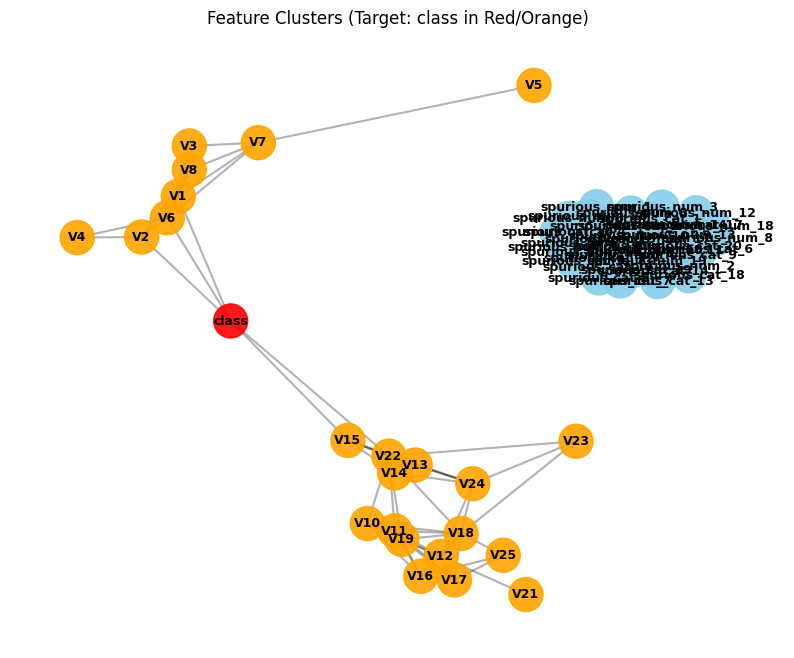

Benchmark -> miniboone
Cluster for 'signal' contains 46 features: ['ParticleID_20', 'ParticleID_45', 'ParticleID_28', 'ParticleID_11', 'ParticleID_24', 'ParticleID_41', 'ParticleID_35', 'ParticleID_48', 'ParticleID_23', 'ParticleID_4', 'ParticleID_8', 'signal', 'ParticleID_39', 'ParticleID_5', 'ParticleID_37', 'ParticleID_22', 'ParticleID_30', 'ParticleID_9', 'ParticleID_1', 'ParticleID_44', 'ParticleID_46', 'ParticleID_36', 'ParticleID_40', 'ParticleID_7', 'ParticleID_16', 'ParticleID_32', 'ParticleID_19', 'ParticleID_33', 'ParticleID_0', 'ParticleID_2', 'ParticleID_14', 'ParticleID_38', 'ParticleID_42', 'ParticleID_27', 'ParticleID_10', 'ParticleID_26', 'ParticleID_31', 'ParticleID_13', 'ParticleID_34', 'ParticleID_47', 'ParticleID_29', 'ParticleID_15', 'ParticleID_6', 'ParticleID_43', 'ParticleID_3', 'ParticleID_25']
{'spurious_num_4', 'spurious_cat_18', 'spurious_cat_8', 'spurious_num_8', 'spurious_num_15', 'spurious_num_10', 'spurious_cat_17', 'spurious_num_2', 'spurious_cat_19', 

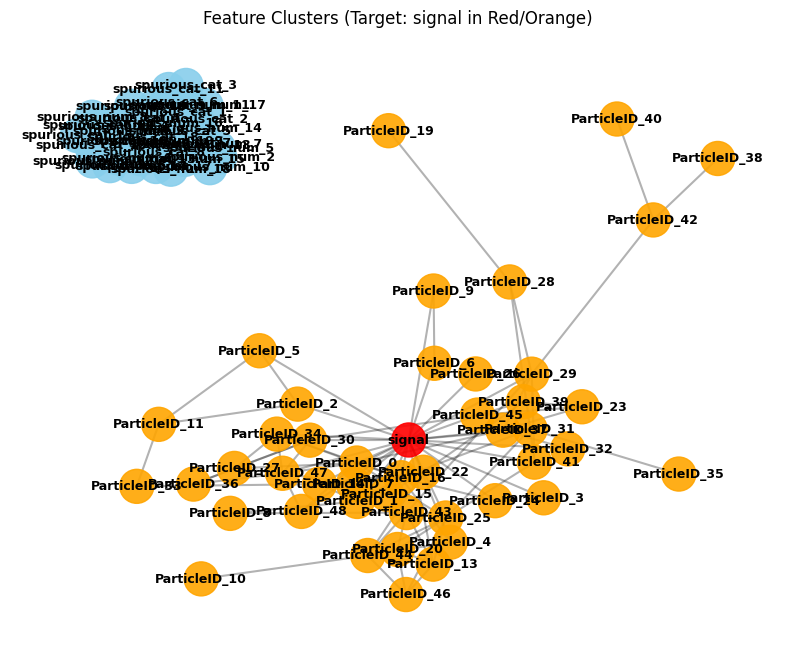

Benchmark -> bank
Cluster for 'Class' contains 12 features: ['V5', 'V16', 'V12', 'V11', 'V9', 'V14', 'V7', 'V10', 'V8', 'Class', 'V15', 'V13']
{'V5', 'V16', 'V12', 'V11', 'V9', 'V14', 'V7', 'V10', 'V8', 'Class', 'V15', 'V13'}
{'spurious_num_4', 'spurious_cat_4', 'spurious_cat_1', 'spurious_cat_5', 'spurious_num_1', 'spurious_num_5', 'spurious_cat_3', 'spurious_num_3', 'spurious_num_6', 'spurious_cat_2', 'spurious_cat_6', 'spurious_num_2'}
{'V2', 'V4'}
{'V3', 'V1'}


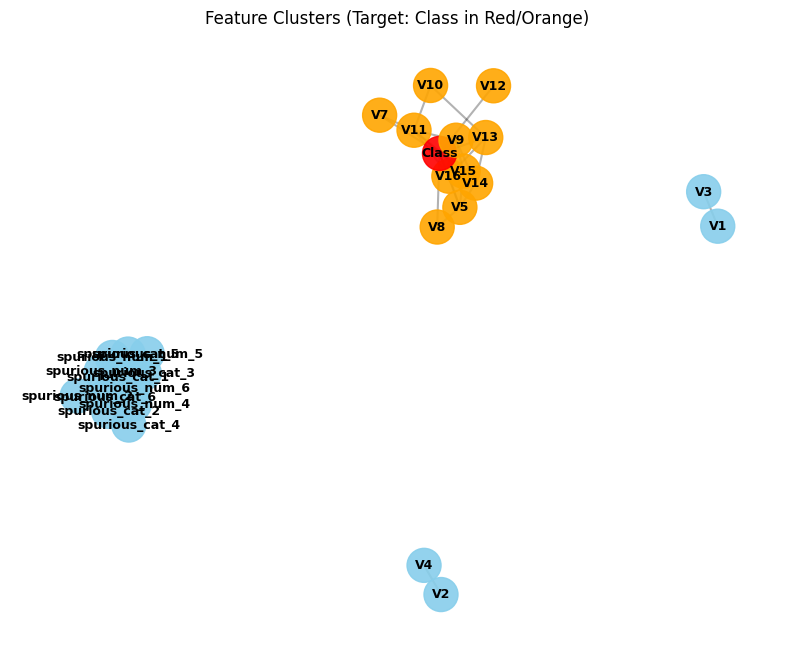

Benchmark -> pendigits
Cluster for 'class' contains 17 features: ['input13', 'input6', 'input2', 'input12', 'input9', 'input15', 'input16', 'class', 'input11', 'input5', 'input10', 'input7', 'input3', 'input8', 'input4', 'input14', 'input1']
{'spurious_num_4', 'spurious_cat_4', 'spurious_cat_1', 'spurious_cat_5', 'spurious_num_1', 'spurious_num_6', 'spurious_num_3', 'spurious_num_5', 'spurious_cat_3', 'spurious_cat_2', 'spurious_cat_6', 'spurious_num_2'}
{'input13', 'input6', 'input2', 'input12', 'input9', 'input15', 'input16', 'class', 'input11', 'input5', 'input10', 'input7', 'input3', 'input8', 'input4', 'input14', 'input1'}


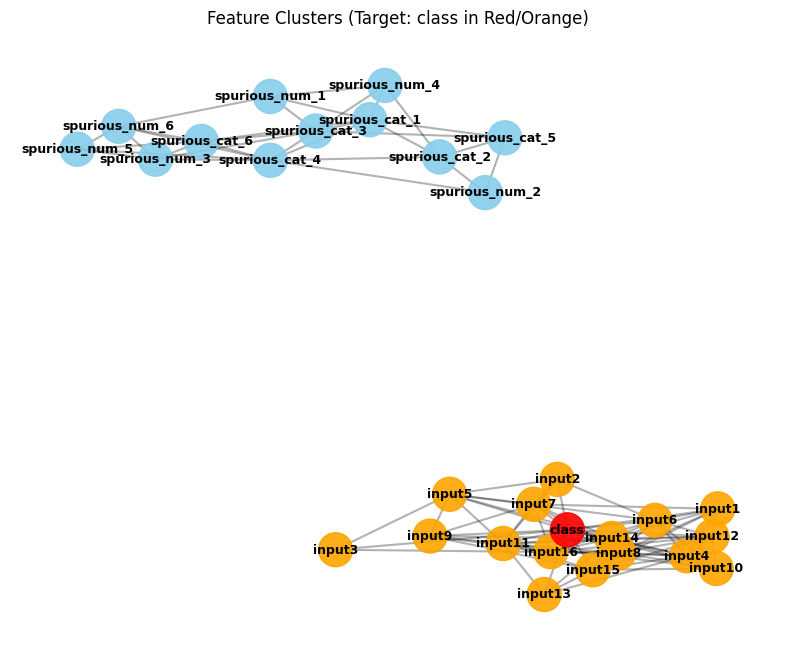

Benchmark -> students
Cluster for 'Target' contains 25 features: ['Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)', 'Age at enrollment', 'Application order', 'Curricular units 2nd sem (grade)', 'Tuition fees up to date', 'Displaced', 'Curricular units 2nd sem (enrolled)', 'Curricular units 1st sem (grade)', 'Previous qualification', 'Marital status', 'Target', 'Gender', 'Application mode', 'Curricular units 1st sem (credited)', 'Debtor', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 2nd sem (credited)', 'Scholarship holder', 'Curricular units 2nd sem (evaluations)', 'Course', 'Previous qualification (grade)', 'Daytime/evening attendance\t', 'Admission grade']
{'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)', 'Age at enrollment', 'Application order', 'Curricular units 2nd sem (grade)', 'Tuition fees up to date', 'Displaced', 'Curricular units 2nd sem (enrolled)', 'Curricular uni

C:\Users\marc.maynou\AppData\Local\Temp\ipykernel_16636\808599081.py:24: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.savefig("cluster_map.png")
c:\Users\marc.maynou\miniconda3\envs\arclo\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


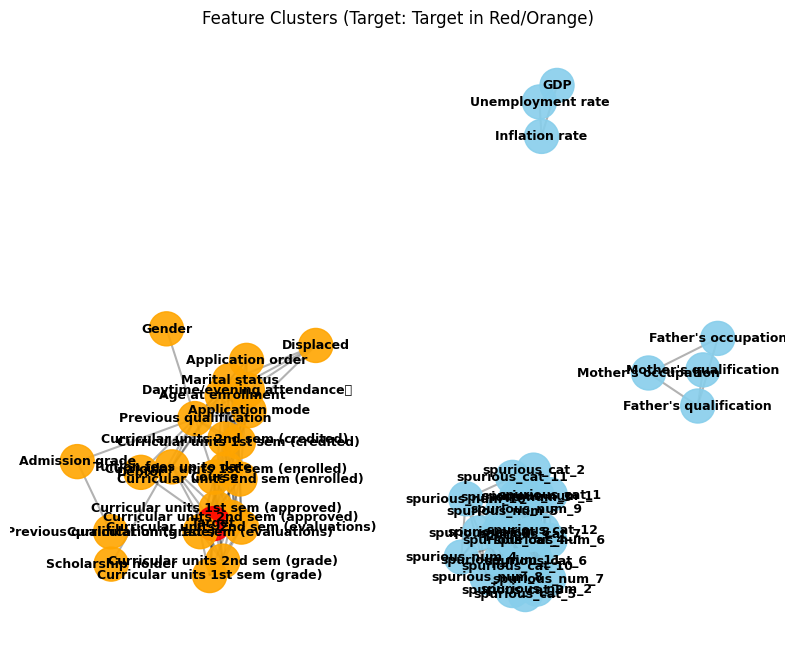

Benchmark -> drive_diagnosis
Cluster for 'RES' contains 48 features: ['NUM3', 'NUM39', 'NUM43', 'NUM9', 'NUM25', 'NUM5', 'NUM38', 'NUM32', 'NUM33', 'NUM47', 'NUM11', 'NUM45', 'NUM24', 'NUM6', 'NUM19', 'NUM28', 'NUM4', 'NUM35', 'NUM44', 'NUM48', 'NUM22', 'NUM12', 'NUM14', 'NUM17', 'NUM41', 'NUM37', 'NUM18', 'NUM36', 'NUM2', 'NUM20', 'NUM15', 'NUM40', 'NUM46', 'RES', 'NUM31', 'NUM10', 'NUM23', 'NUM30', 'NUM26', 'NUM34', 'NUM7', 'NUM1', 'NUM16', 'NUM8', 'NUM13', 'NUM29', 'NUM21', 'NUM27']
{'NUM3', 'NUM39', 'NUM43', 'NUM9', 'NUM25', 'NUM5', 'NUM38', 'NUM32', 'NUM33', 'NUM47', 'NUM11', 'NUM45', 'NUM24', 'NUM6', 'NUM19', 'NUM28', 'NUM4', 'NUM35', 'NUM44', 'NUM48', 'NUM22', 'NUM12', 'NUM14', 'NUM17', 'NUM41', 'NUM37', 'NUM18', 'NUM36', 'NUM2', 'NUM20', 'NUM15', 'NUM40', 'NUM46', 'RES', 'NUM31', 'NUM10', 'NUM23', 'NUM30', 'NUM26', 'NUM34', 'NUM7', 'NUM1', 'NUM16', 'NUM8', 'NUM13', 'NUM29', 'NUM21', 'NUM27'}
{'spurious_num_4', 'spurious_cat_18', 'spurious_cat_8', 'spurious_num_8', 'spurious_num

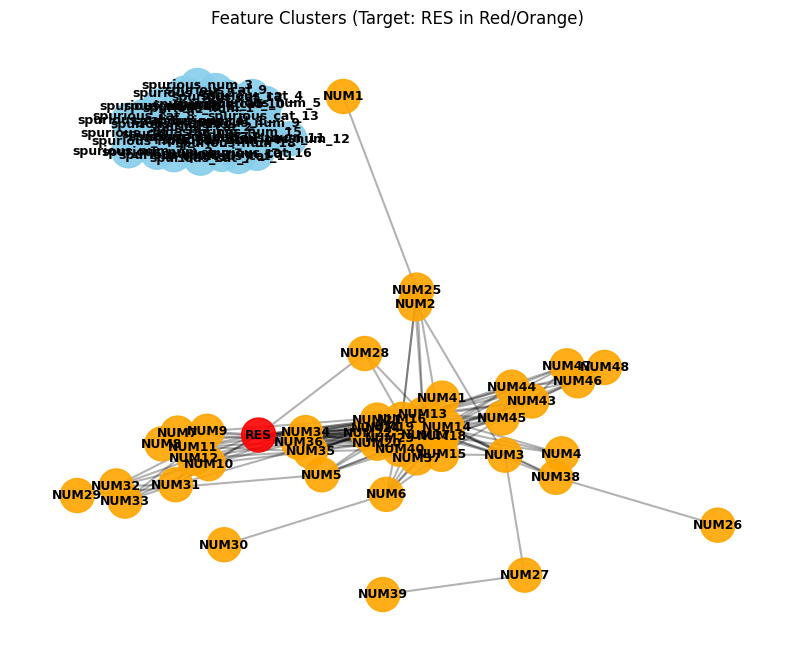

Benchmark -> covertype
Cluster for 'class' contains 4 features: ['Wilderness_Area', 'class', 'Soil_Type', 'Elevation']
{'spurious_num_4', 'spurious_cat_4', 'Hillshade_9am_shuffled_1', 'spurious_cat_1', 'spurious_cat_5', 'spurious_num_1', 'spurious_num_3', 'spurious_cat_2', 'spurious_cat_3', 'spurious_num_2'}
{'Hillshade_3pm', 'Hillshade_Noon', 'Slope', 'Hillshade_9am', 'Aspect'}
{'Wilderness_Area', 'class', 'Soil_Type', 'Elevation'}
{'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology'}


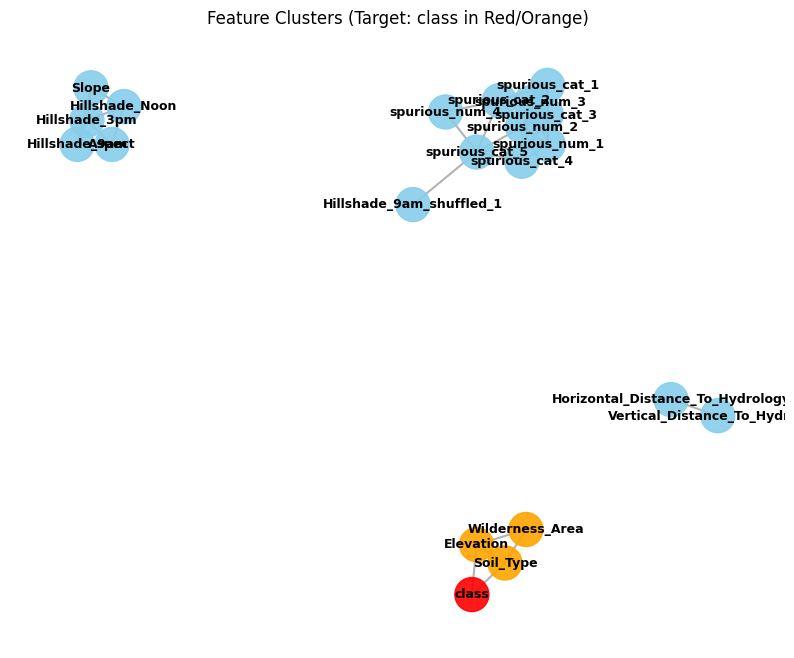

Benchmark -> default_payment
Cluster for 'default' contains 20 features: ['PAY_0', 'BILL_AMT5', 'PAY_AMT2', 'PAY_AMT4', 'PAY_4', 'PAY_AMT5', 'default', 'PAY_5', 'BILL_AMT4', 'PAY_AMT3', 'PAY_6', 'BILL_AMT6', 'PAY_2', 'BILL_AMT3', 'LIMIT_BAL', 'PAY_AMT1', 'BILL_AMT1', 'BILL_AMT2', 'PAY_3', 'PAY_AMT6']
{'PAY_0', 'BILL_AMT5', 'PAY_AMT2', 'PAY_AMT4', 'PAY_4', 'PAY_AMT5', 'default', 'PAY_5', 'BILL_AMT4', 'PAY_AMT3', 'PAY_6', 'BILL_AMT6', 'PAY_2', 'BILL_AMT3', 'LIMIT_BAL', 'PAY_AMT1', 'BILL_AMT1', 'BILL_AMT2', 'PAY_3', 'PAY_AMT6'}
{'spurious_num_4', 'spurious_cat_8', 'spurious_cat_4', 'spurious_cat_9', 'spurious_cat_1', 'spurious_cat_5', 'spurious_num_8', 'spurious_num_1', 'spurious_num_6', 'spurious_num_3', 'spurious_cat_3', 'spurious_num_5', 'spurious_num_7', 'spurious_cat_2', 'spurious_cat_6', 'spurious_num_2', 'spurious_cat_7'}
{'AGE', 'MARRIAGE'}


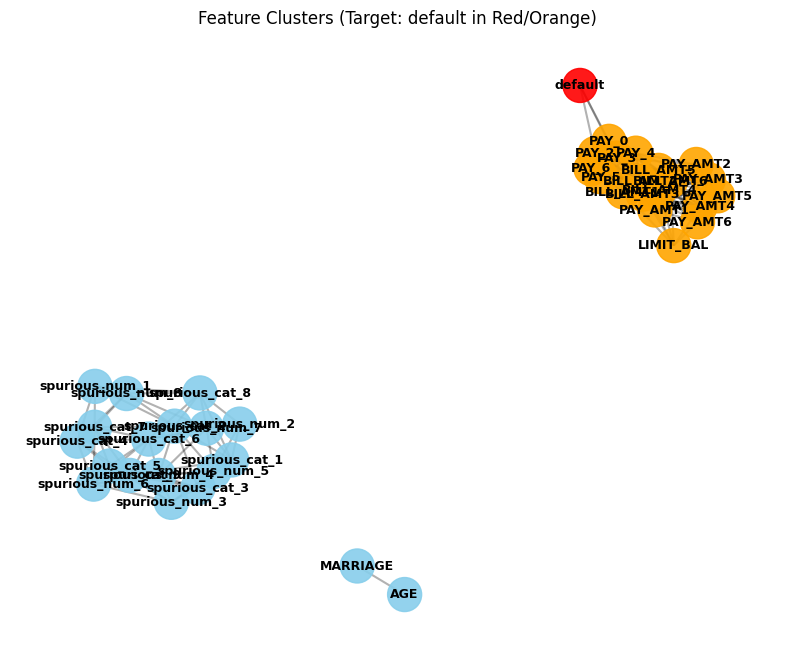

Benchmark -> dry_beans
Cluster for 'Class' contains 16 features: ['Eccentricity', 'Area', 'ShapeFactor3', 'MajorAxisLength', 'Compactness', 'roundness', 'AspectRation', 'EquivDiameter', 'Solidity', 'ShapeFactor2', 'Perimeter', 'ShapeFactor4', 'ShapeFactor1', 'MinorAxisLength', 'Class', 'ConvexArea']
{'Eccentricity', 'Area', 'ShapeFactor3', 'MajorAxisLength', 'Compactness', 'roundness', 'AspectRation', 'EquivDiameter', 'Solidity', 'ShapeFactor2', 'Perimeter', 'ShapeFactor4', 'ShapeFactor1', 'MinorAxisLength', 'Class', 'ConvexArea'}
{'spurious_num_4', 'spurious_cat_4', 'spurious_cat_1', 'spurious_cat_5', 'spurious_num_1', 'spurious_num_5', 'spurious_cat_3', 'spurious_cat_2', 'spurious_num_3', 'spurious_num_6', 'spurious_cat_6', 'spurious_num_2'}


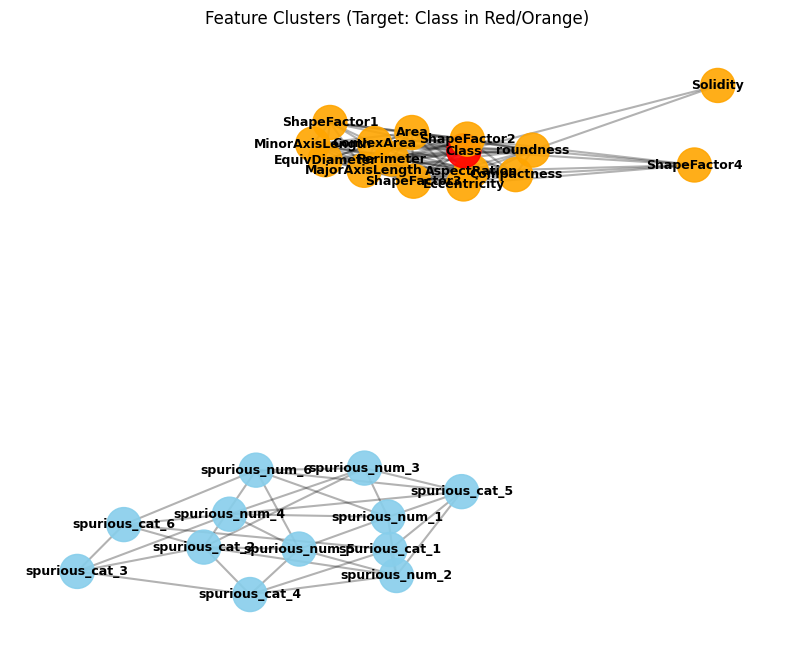

Note: 'class' has no relations >= 4.0. Returning only target.
Benchmark -> mice_protein
Cluster for 'class' contains 1 features: ['class']


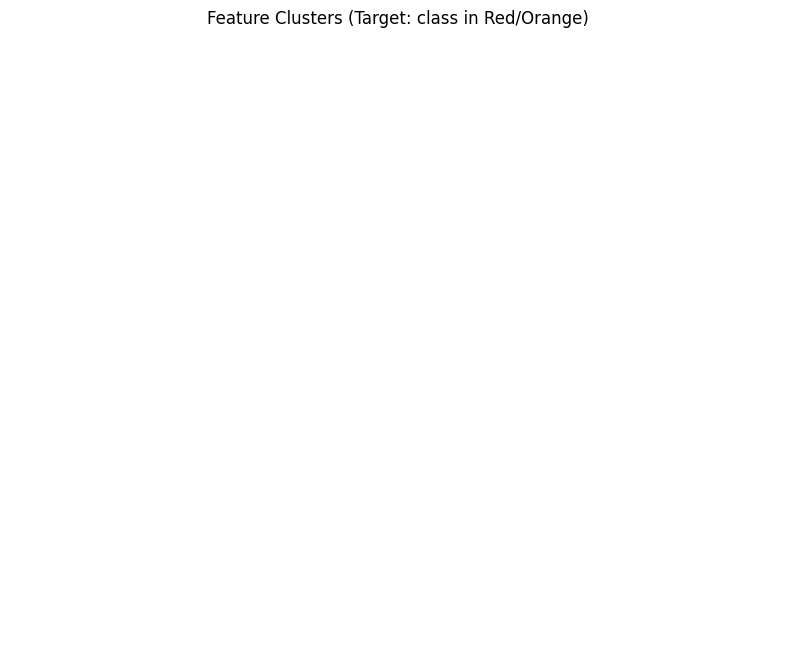

Benchmark -> house_sales
Cluster for 'price' contains 14 features: ['grade', 'lat', 'waterfront', 'bedrooms', 'sqft_lot', 'sqft_above', 'yr_built', 'sqft_lot15', 'long', 'sqft_basement', 'price', 'sqft_living', 'bathrooms', 'sqft_living15']
{'spurious_num_4', 'spurious_cat_4', 'spurious_cat_1', 'spurious_cat_5', 'spurious_num_1', 'spurious_num_6', 'spurious_num_3', 'spurious_cat_2', 'spurious_cat_3', 'spurious_num_5', 'spurious_cat_6', 'spurious_num_2', 'spurious_cat_7'}
{'date_year', 'date_month'}
{'grade', 'lat', 'waterfront', 'bedrooms', 'sqft_lot', 'sqft_above', 'yr_built', 'sqft_lot15', 'long', 'sqft_basement', 'price', 'sqft_living', 'bathrooms', 'sqft_living15'}


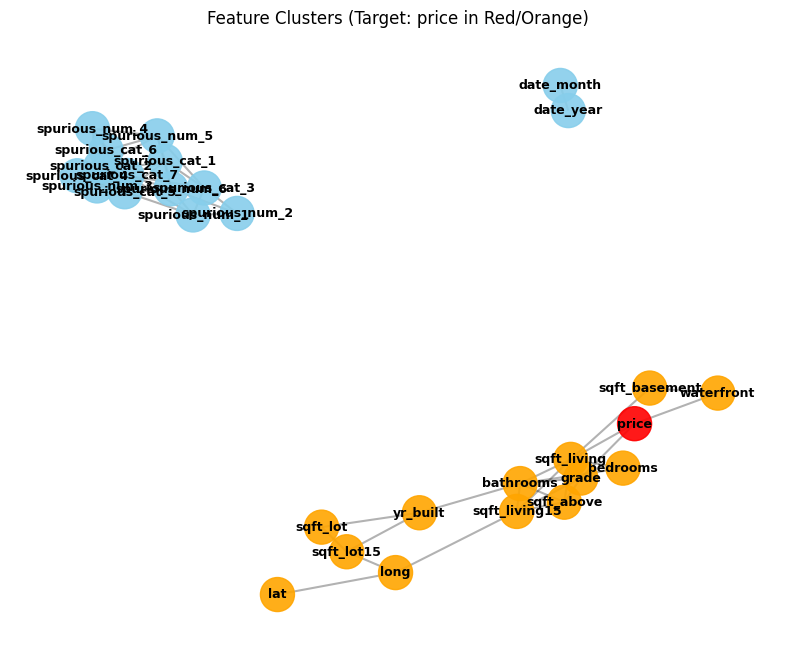

Benchmark -> avocado_sales
Cluster for 'AveragePrice' contains 11 features: ['type', 'Small Bags', 'XLarge Bags', 'region', 'Large Bags', 'Total Volume', '4046', 'Total Bags', 'AveragePrice', '4225', '4770']
{'type', 'Small Bags', 'XLarge Bags', 'region', 'Large Bags', 'Total Volume', '4046', 'Total Bags', 'AveragePrice', '4225', '4770'}
{'spurious_num_4', 'spurious_cat_4', 'spurious_cat_1', 'spurious_cat_5', 'spurious_num_1', 'spurious_num_5', 'spurious_cat_3', 'spurious_cat_2', 'spurious_num_3', 'spurious_num_2'}


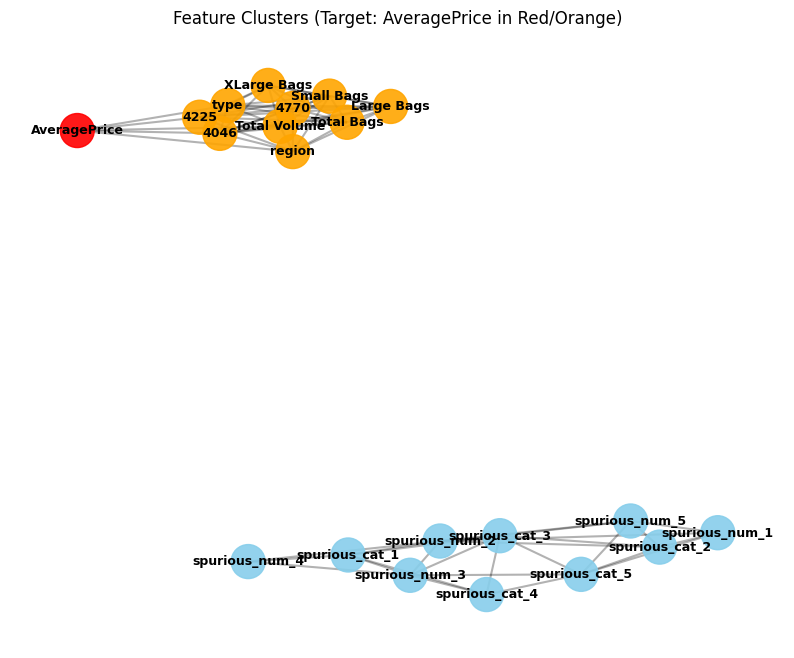

Benchmark -> nasa
Cluster for 'class' contains 13 features: ['sensor_15', 'sensor_2', 'sensor_3', 'sensor_14', 'sensor_17', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_11', 'sensor_13', 'sensor_9', 'class', 'sensor_12']
{'sensor_5', 'sensor_10', 'sensor_6', 'sensor_16', 'sensor_1'}
{'spurious_cat_8', 'spurious_num_4', 'spurious_cat_4', 'spurious_cat_1', 'spurious_cat_5', 'spurious_num_8', 'spurious_num_1', 'spurious_num_5', 'spurious_num_3', 'spurious_cat_3', 'spurious_cat_2', 'spurious_num_7', 'spurious_num_6', 'spurious_cat_6', 'spurious_num_2', 'spurious_cat_7'}
{'sensor_15', 'sensor_2', 'sensor_3', 'sensor_14', 'sensor_17', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_11', 'sensor_13', 'sensor_9', 'class', 'sensor_12'}


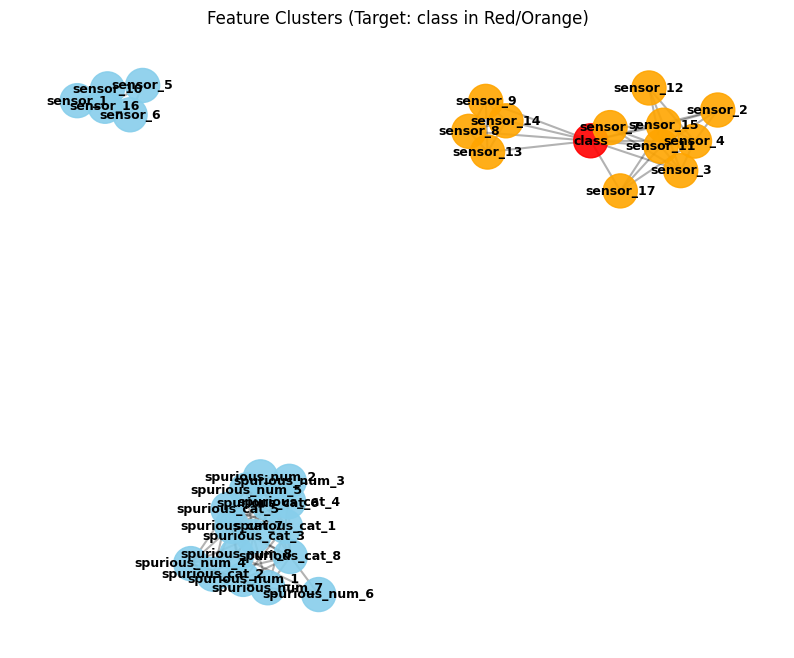

Benchmark -> diamonds
Cluster for 'price' contains 10 features: ['carat', 'y', 'x', 'depth', 'color', 'z', 'clarity', 'cut', 'price', 'table']
{'carat', 'y', 'x', 'depth', 'color', 'z', 'clarity', 'cut', 'price', 'table'}
{'spurious_cat_4', 'spurious_cat_1', 'spurious_num_1', 'spurious_cat_3', 'spurious_cat_2', 'spurious_num_3', 'spurious_num_2'}


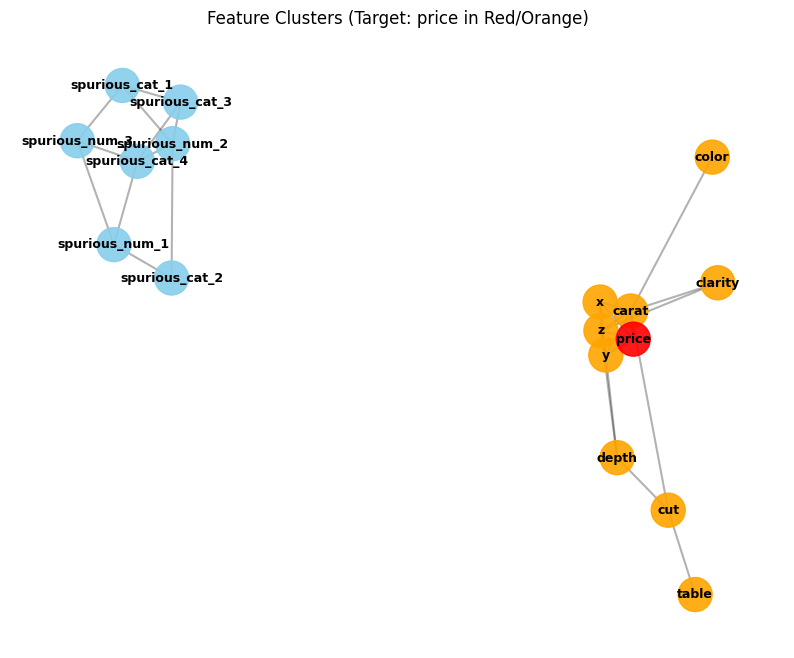

Benchmark -> pol
Cluster for 'foo' contains 16 features: ['f13', 'f7', 'f16', 'f17', 'f9', 'f19', 'f20', 'f15', 'f6', 'f8', 'f23', 'f18', 'f14', 'f21', 'f22', 'foo']
{'spurious_num_4', 'spurious_cat_8', 'spurious_cat_18', 'spurious_num_8', 'spurious_num_15', 'spurious_num_10', 'spurious_cat_17', 'spurious_num_2', 'spurious_num_11', 'spurious_cat_10', 'spurious_cat_12', 'spurious_cat_4', 'spurious_cat_11', 'spurious_num_13', 'spurious_cat_1', 'spurious_num_6', 'spurious_cat_3', 'spurious_cat_15', 'spurious_num_16', 'spurious_cat_7', 'spurious_num_9', 'spurious_num_1', 'spurious_cat_6', 'spurious_cat_16', 'spurious_cat_14', 'spurious_cat_13', 'spurious_cat_9', 'spurious_num_17', 'spurious_num_14', 'spurious_cat_5', 'spurious_num_5', 'spurious_num_3', 'spurious_cat_2', 'spurious_num_18', 'spurious_num_7', 'spurious_num_12'}
{'f13', 'f7', 'f16', 'f17', 'f9', 'f19', 'f20', 'f15', 'f6', 'f8', 'f23', 'f18', 'f14', 'f21', 'f22', 'foo'}


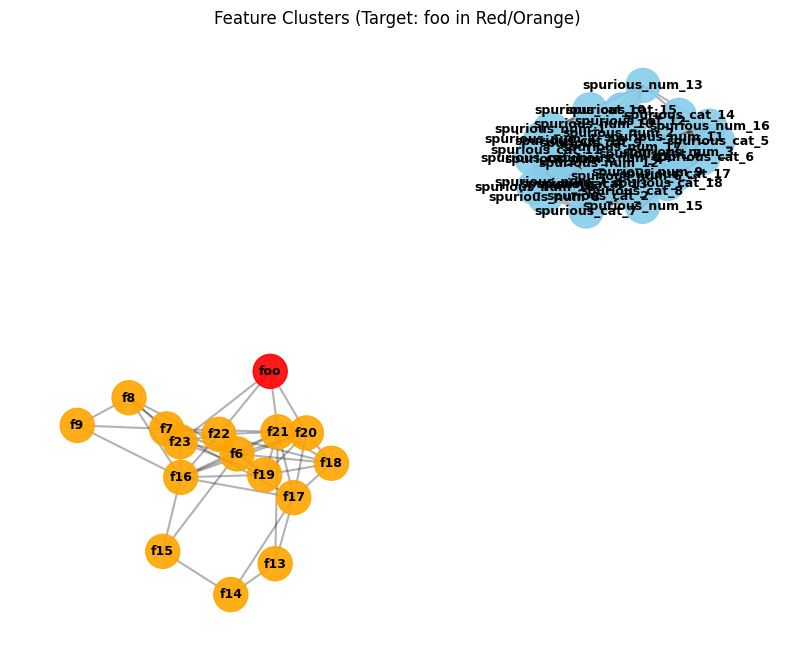

Benchmark -> appliances
Cluster for 'Appliances' contains 26 features: ['Visibility', 'RH_6', 'Appliances', 'Tdewpoint', 'T4', 'T5', 'RH_3', 'T_out', 'RH_9', 'RH_out', 'RH_8', 'T7', 'lights', 'RH_5', 'T6', 'T8', 'T3', 'Windspeed', 'Press_mm_hg', 'RH_2', 'RH_1', 'T1', 'T2', 'RH_7', 'RH_4', 'T9']
{'spurious_cat_8', 'spurious_num_4', 'spurious_num_8', 'spurious_num_10', 'spurious_num_2', 'spurious_cat_10', 'spurious_cat_4', 'spurious_cat_1', 'spurious_num_6', 'spurious_cat_3', 'spurious_cat_7', 'spurious_num_9', 'spurious_num_1', 'spurious_cat_6', 'spurious_cat_9', 'spurious_cat_5', 'spurious_num_5', 'spurious_num_3', 'spurious_cat_2', 'spurious_num_7'}
{'Visibility', 'RH_6', 'Appliances', 'Tdewpoint', 'T4', 'T5', 'RH_3', 'T_out', 'RH_9', 'RH_out', 'RH_8', 'T7', 'lights', 'RH_5', 'T6', 'T8', 'T3', 'Windspeed', 'Press_mm_hg', 'RH_2', 'RH_1', 'T1', 'T2', 'RH_7', 'RH_4', 'T9'}
{'rv1', 'rv2'}


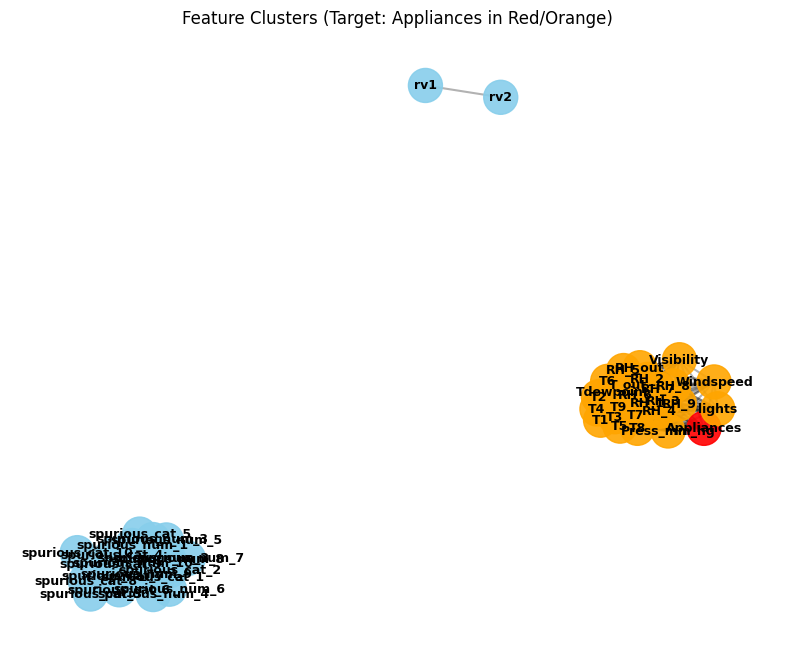

Note: 'critical_temp' has no relations >= 4.0. Returning only target.
Benchmark -> superconductivity
Cluster for 'critical_temp' contains 1 features: ['critical_temp']


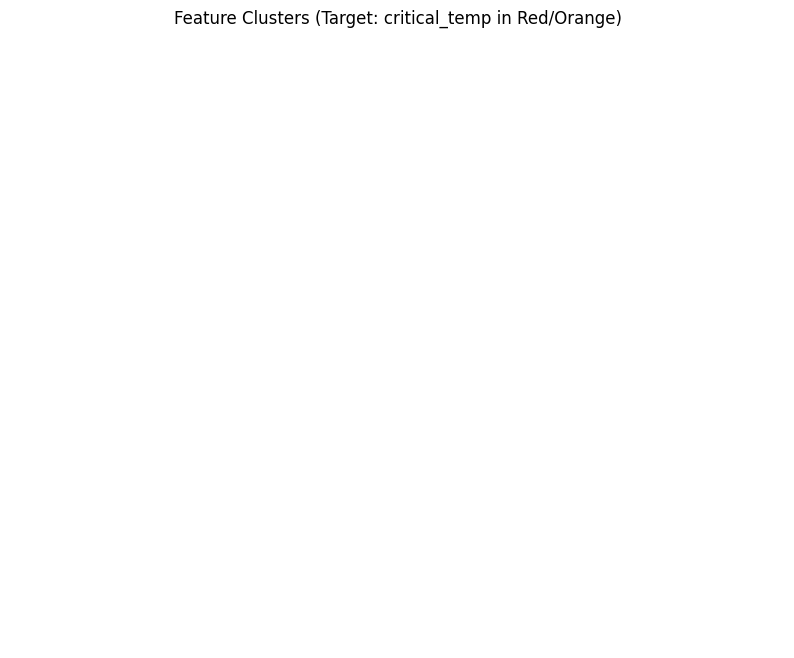

In [5]:
import yaml

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

def visualize_clusters(G, clusters, target_feature):
    target_cluster = next((c for c in clusters if target_feature in c), set())

    node_colors = [
        "red"     if node == target_feature  else
        "orange"  if node in target_cluster  else
        "skyblue"
        for node in G.nodes()
    ]

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.6, seed=42)
    nx.draw_networkx_nodes(G, pos, node_size=600, node_color=node_colors, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=1.5, alpha=0.3)
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight="bold")
    plt.title(f"Feature Clusters (Target: {target_feature} in Red/Orange)")
    plt.axis("off")
    plt.savefig("cluster_map.png")
    plt.show()


def build_graph_from_soundness(soundness_df: pd.DataFrame, threshold: float) -> nx.Graph:
    """
    Build an undirected graph from a soundness triple DataFrame.

    Edges with score <= threshold or self-loops are excluded.
    When multiple rows describe the same pair, only the highest score is kept.
    """
    expected_cols = {"column_1", "column_2", "soundness"}
    if not expected_cols.issubset(soundness_df.columns):
        raise ValueError(f"DataFrame must contain columns {expected_cols}")

    df = soundness_df.copy()
    df["column_1"] = df["column_1"].astype(str)
    df["column_2"] = df["column_2"].astype(str)
    df["soundness"] = pd.to_numeric(df["soundness"], errors="coerce")

    df = df.dropna(subset=["soundness"])
    df = df[df["column_1"] != df["column_2"]] # drop self-loops
    df = df[df["soundness"] > threshold]  # apply threshold

    # Keep only the highest score per unordered pair
    df["_pair"] = df.apply(lambda r: frozenset((r["column_1"], r["column_2"])), axis=1)
    df = df.sort_values("soundness", ascending=False).drop_duplicates("_pair")

    graph = nx.Graph()
    for _, row in df.iterrows():
        graph.add_edge(row["column_1"], row["column_2"], weight=float(row["soundness"]))

    return graph


def filter_columns(columns: list[str], df: pd.DataFrame, include_synth_targets: bool = False) -> list[str]:
    """Return only those column names that actually exist in df."""
    if not include_synth_targets:
        return [col for col in columns if col in df.columns]
    else:
        return [col for col in columns if col in df.columns or col in ["synthetic_target_1", "synthetic_target_2"]]


with open("../benchmarks.yaml") as f:
    benchmarks_data = yaml.safe_load(f)
    names = list(benchmarks_data.keys())

    threshold = 4.0

    for benchmark_name in names:
        benchmark_configuration = benchmarks_data[benchmark_name]
        target_column = benchmark_configuration["target_column"]

        base_dataset = pd.read_csv(f"../data/base_datasets/{benchmark_name}.csv")
        soundness_df = pd.read_csv(f"../data/output/output_{benchmark_name}_cf2.csv")

        graph = build_graph_from_soundness(soundness_df, threshold=threshold)
        all_clusters = list(nx.connected_components(graph)) # Detect clusters of related features (connected components).

        target_cluster = next( # Identify the cluster containing target_column
            (c for c in all_clusters if target_column in c),
            {target_column},   # fallback: cluster of one
        )

        if target_column not in graph:
            print(f"Note: '{target_column}' has no relations >= {threshold}. Returning only target.")

        selected_cols = filter_columns(list(target_cluster), base_dataset)
        print(f"Benchmark -> {benchmark_name}")
        print(f"Cluster for '{target_column}' contains {len(selected_cols)} features: {selected_cols}")
        for cluster in all_clusters:
            print(cluster)

        visualize_clusters(graph, all_clusters, target_column)

C:\Users\marc.maynou\AppData\Local\Temp\ipykernel_16048\1262519619.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


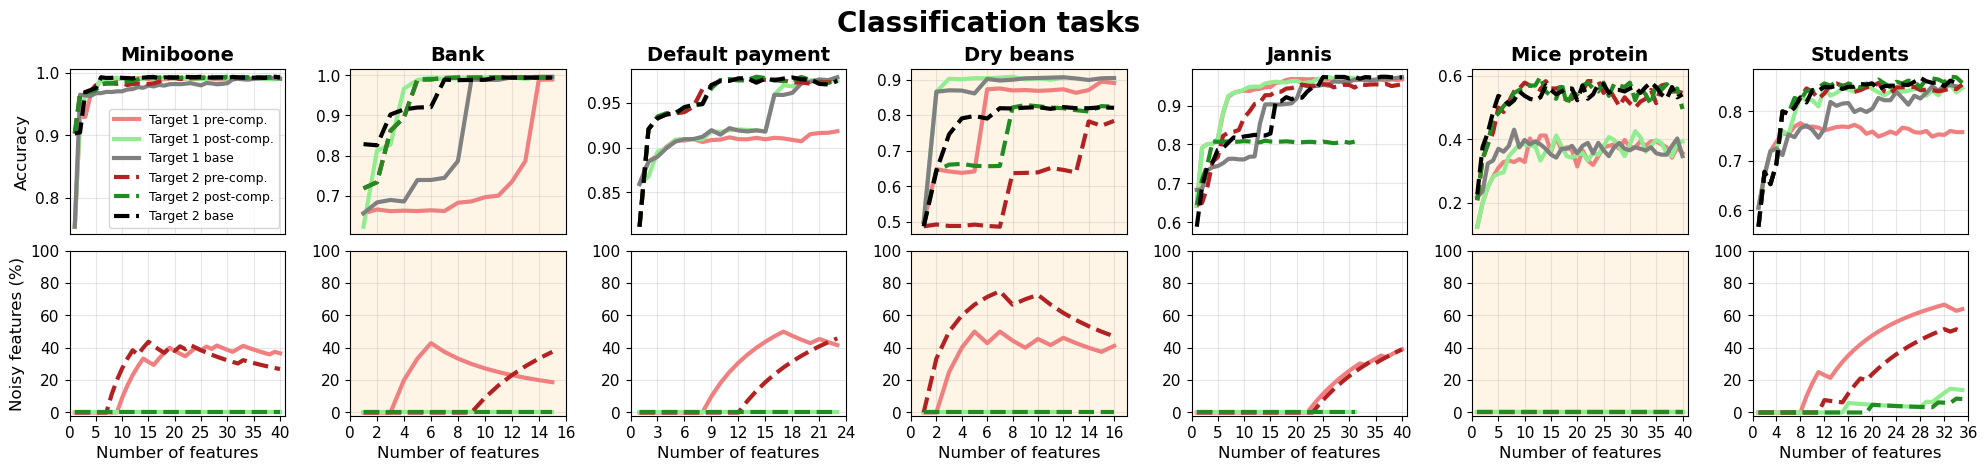

C:\Users\marc.maynou\AppData\Local\Temp\ipykernel_16048\1262519619.py:350: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


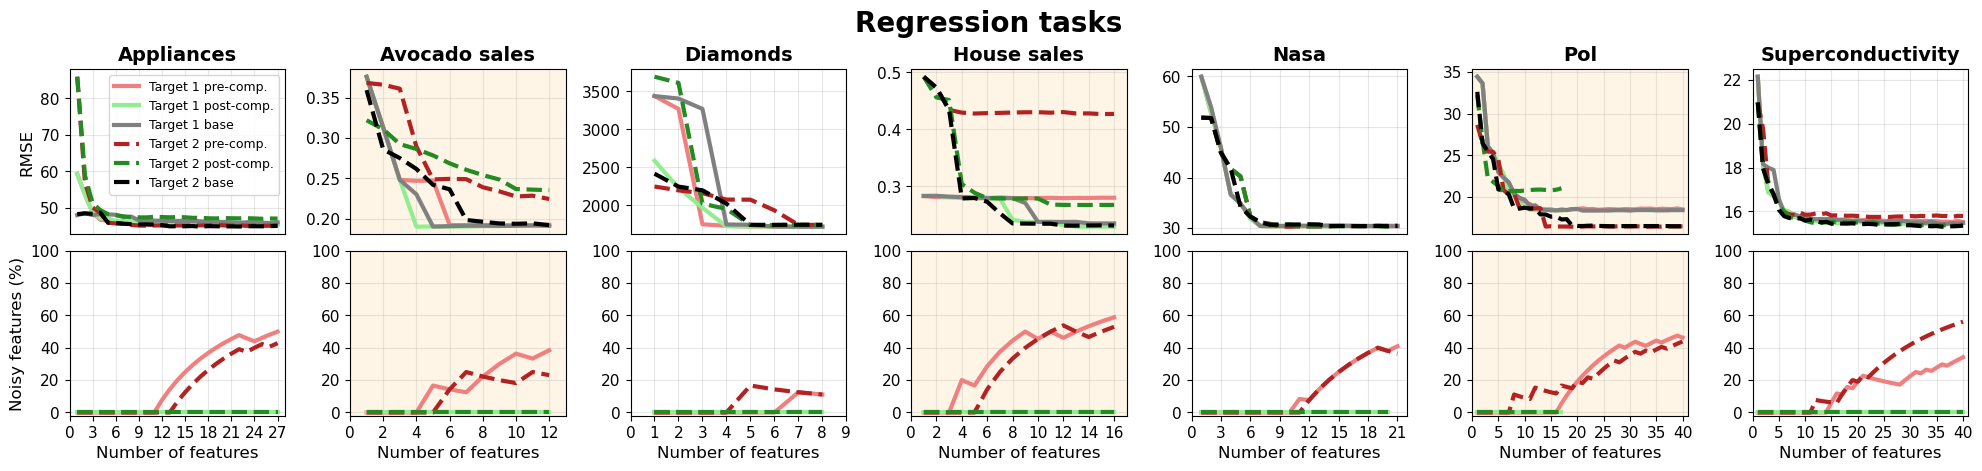

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.ticker import MaxNLocator

##### CONFIG

FILES = {
    "classification": "results_2targets_classification.csv",
    "regression": "results_2targets_regression.csv",
}

NOISY_PATTERNS = ["noise_", "_shuffled_", "spurious_"]

variants = {
    "target_1_noise": {
        "suffix": "_synthetic_target_1_noise",
        "color": "lightcoral",
        "label": "Target 1 pre-comp.",
        "linestyle": "-",
        "marker": "o",
    },
    "target_1_clean": {
        "suffix": "_synthetic_target_1_clean",
        "color": "lightgreen",
        "label": "Target 1 post-comp.",
        "linestyle": "-",
        "marker": "o",
    },
    "target_1_base": {
        "suffix": "_synthetic_target_1_base",
        "color": "grey",
        "label": "Target 1 base",
        "linestyle": "-",
        "marker": "o",
    },
    "target_2_noise": {
        "suffix": "_synthetic_target_2_noise",
        "color": "firebrick",
        "label": "Target 2 pre-comp.",
        "linestyle": "--",
        "marker": "o",
    },
    "target_2_clean": {
        "suffix": "_synthetic_target_2_clean",
        "color": "forestgreen",
        "label": "Target 2 post-comp.",
        "linestyle": "--",
        "marker": "o",
    },
    "target_2_base": {
        "suffix": "_synthetic_target_2_base",
        "color": "black",
        "label": "Target 2 base",
        "linestyle": "--",
        "marker": "o",
    },
}

STYLE = {"title_size": 14, "label_size": 12, "tick_size": 11, "legend_size": 9, 
         "pair_hspace": 0.1, "group_hspace": -0.08, "fig_w": 3.5, "fig_h": 3, "pair_wspace": 0.3}


MAX_FEATURES_PER_BENCHMARK = {
    "bank": 15,
    "default_payment": 23,
    "jannis": 40,  # 53
    "miniboone": 40,  # 49
    "appliances": 27,
    "avocado_sales": 12,
    "diamonds": 8,
    "house_sales": 16,
    "nasa": 21,
    "pol": 40,  # 47
    "superconductivity": 40,  # 81
    "covertype": 12,
    "drive_diagnosis": 40,  # 47
    "dry_beans": 16,
    "mice_protein": 40,  # 80
    "pendigits": 16,
    "students": 35,
}

# Define the two alternating background colors for columns
COLUMN_COLORS = ["#ffffff", "#fff5e6"]

###### HELPERS

def compute_noisy_percentage(selected_features_str):
    if pd.isna(selected_features_str) or selected_features_str == "":
        return np.nan

    features = [f.strip() for f in selected_features_str.split(",")]

    if len(features) == 0:
        return np.nan

    noisy_count = sum(
        any(p in feat for p in NOISY_PATTERNS)
        for feat in features
    )

    return 100.0 * noisy_count / len(features)


def get_base_benchmark(name):
    suffixes = [
        "_synthetic_target_1_noise",
        "_synthetic_target_1_clean",
        "_synthetic_target_2_noise",
        "_synthetic_target_2_clean",
        "_synthetic_target_1_base",
        "_synthetic_target_2_base",
    ]

    for s in suffixes:
        if name.endswith(s):
            return name[:-len(s)]

    return name


def plot_dataset(df, task_type, metric_col, metric_label):

    df = df.copy()
    df["noisy_percentage"] = df["selected_features"].apply(
        compute_noisy_percentage
    )

    base_benchmarks = sorted(
        set(get_base_benchmark(b) for b in df["benchmark"].unique())
    )

    if task_type == "classification":
        for dataset in ["pendigits", "covertype", "drive_diagnosis"]:
            if dataset in base_benchmarks:
                base_benchmarks.remove(dataset)
        base_benchmarks = ["miniboone"] + [col for col in base_benchmarks if col != "miniboone"]

    ncols = 7
    nrows = math.ceil(len(base_benchmarks) / ncols)

    fig = plt.figure(
        figsize=(STYLE["fig_w"] * ncols,
                 STYLE["fig_h"] * nrows * 1.5)
    )

    subfigs = fig.subfigures(
        nrows,
        1,
        hspace=STYLE["group_hspace"]
    )

    if nrows == 1:
        subfigs = [subfigs]

    bottom_axes_per_row = []
    top_axes_per_row = []

    for row_idx, subfig in enumerate(subfigs):

        if row_idx == 0:
            subfig.text(
                0.5,
                0.95,
                "Classification tasks"
                if task_type == "classification"
                else "Regression tasks",
                ha="center",
                va="bottom",
                fontsize=20,
                fontweight="bold",
            )

        subfig.patch.set_alpha(0.55)

        axes_grid = subfig.subplots(
            2,
            ncols,
            sharex=False,
            gridspec_kw={"hspace": STYLE["pair_hspace"], "wspace": STYLE["pair_wspace"]},
        )

        if ncols == 1:
            axes_grid = axes_grid.reshape(2, 1)

        row_bottom_axes = []
        row_top_axes = []

        for col_idx in range(ncols):

            bench_idx = row_idx * ncols + col_idx

            if bench_idx >= len(base_benchmarks):
                subfig.delaxes(axes_grid[0, col_idx])
                subfig.delaxes(axes_grid[1, col_idx])
                continue

            base = base_benchmarks[bench_idx]

            ax_top = axes_grid[0, col_idx]
            ax_bottom = axes_grid[1, col_idx]

            # Alternate background color per column
            bg_color = COLUMN_COLORS[col_idx % len(COLUMN_COLORS)]
            ax_top.set_facecolor(bg_color)
            ax_bottom.set_facecolor(bg_color)

            # Remove x ticks from top subplot
            ax_top.tick_params(
                axis="x",
                bottom=False,
                labelbottom=False,
            )

            row_top_axes.append(ax_top)
            row_bottom_axes.append(ax_bottom)

            for _, cfg in variants.items():

                subset = df[
                    df["benchmark"] == base + cfg["suffix"]
                ]

                if subset.empty:
                    continue

                grouped = (
                    subset.groupby("num_new_features")
                    .agg(
                        {
                            metric_col: "mean",
                            "noisy_percentage": "mean",
                        }
                    )
                    .reset_index()
                    .sort_values("num_new_features")
                )

                max_features = MAX_FEATURES_PER_BENCHMARK.get(
                    base,
                    None,
                )

                if max_features is not None:
                    grouped = grouped[
                        grouped["num_new_features"]
                        <= max_features
                    ]

                ax_top.plot(
                    grouped["num_new_features"],
                    grouped[metric_col],
                    # marker=cfg["marker"],
                    linestyle=cfg["linestyle"],
                    color=cfg["color"],
                    label=cfg["label"],
                    linewidth=3,
                    markevery=4,
                )

                # Plot noisy-feature percentage only for
                # pre/post-clean variants
                if "base" not in cfg["label"]:
                    ax_bottom.plot(
                        grouped["num_new_features"],
                        grouped["noisy_percentage"],
                        # marker=cfg["marker"],
                        linestyle=cfg["linestyle"],
                        color=cfg["color"],
                        linewidth=3,
                        markevery=4,
                    )

                if max_features is not None:
                    ax_top.set_xlim(
                        0,
                        max_features + 1,
                    )
                    ax_bottom.set_xlim(
                        0,
                        max_features + 1,
                    )

                ax_top.xaxis.set_major_locator(
                    MaxNLocator(integer=True)
                )
                ax_bottom.xaxis.set_major_locator(
                    MaxNLocator(integer=True)
                )

                ax_bottom.set_ylim(-2, 100)
                ax_bottom.set_yticks(
                    np.arange(0, 101, 20)
                )

            clean_base = (
                base.replace("_", " ")
                .capitalize()
            )

            ax_top.set_title(
                clean_base,
                fontsize=STYLE["title_size"],
                fontweight="bold",
            )

            if col_idx == 0:
                ax_top.set_ylabel(
                    metric_label,
                    fontsize=STYLE["label_size"],
                )

                ax_bottom.set_ylabel(
                    "Noisy features (%)",
                    fontsize=STYLE["label_size"],
                )

            ax_bottom.set_xlabel(
                "Number of features",
                fontsize=STYLE["label_size"],
            )

            ax_top.tick_params(
                axis="both",
                labelsize=STYLE["tick_size"],
            )

            ax_bottom.tick_params(
                axis="both",
                labelsize=STYLE["tick_size"],
            )

            ax_top.grid(True, alpha=0.3)
            ax_bottom.grid(True, alpha=0.3)

            if bench_idx == 0:
                ax_top.legend(
                    fontsize=STYLE["legend_size"]
                )

        bottom_axes_per_row.append(
            row_bottom_axes
        )
        top_axes_per_row.append(
            row_top_axes
        )

    plt.tight_layout()
    plt.show()


df_class = pd.read_csv(
    FILES["classification"]
)

df_reg = pd.read_csv(
    FILES["regression"]
)

plot_dataset(
    df_class,
    task_type="classification",
    metric_col="test_accuracy",
    metric_label="Accuracy",
)

plot_dataset(
    df_reg,
    task_type="regression",
    metric_col="test_rmse",
    metric_label="RMSE",
)


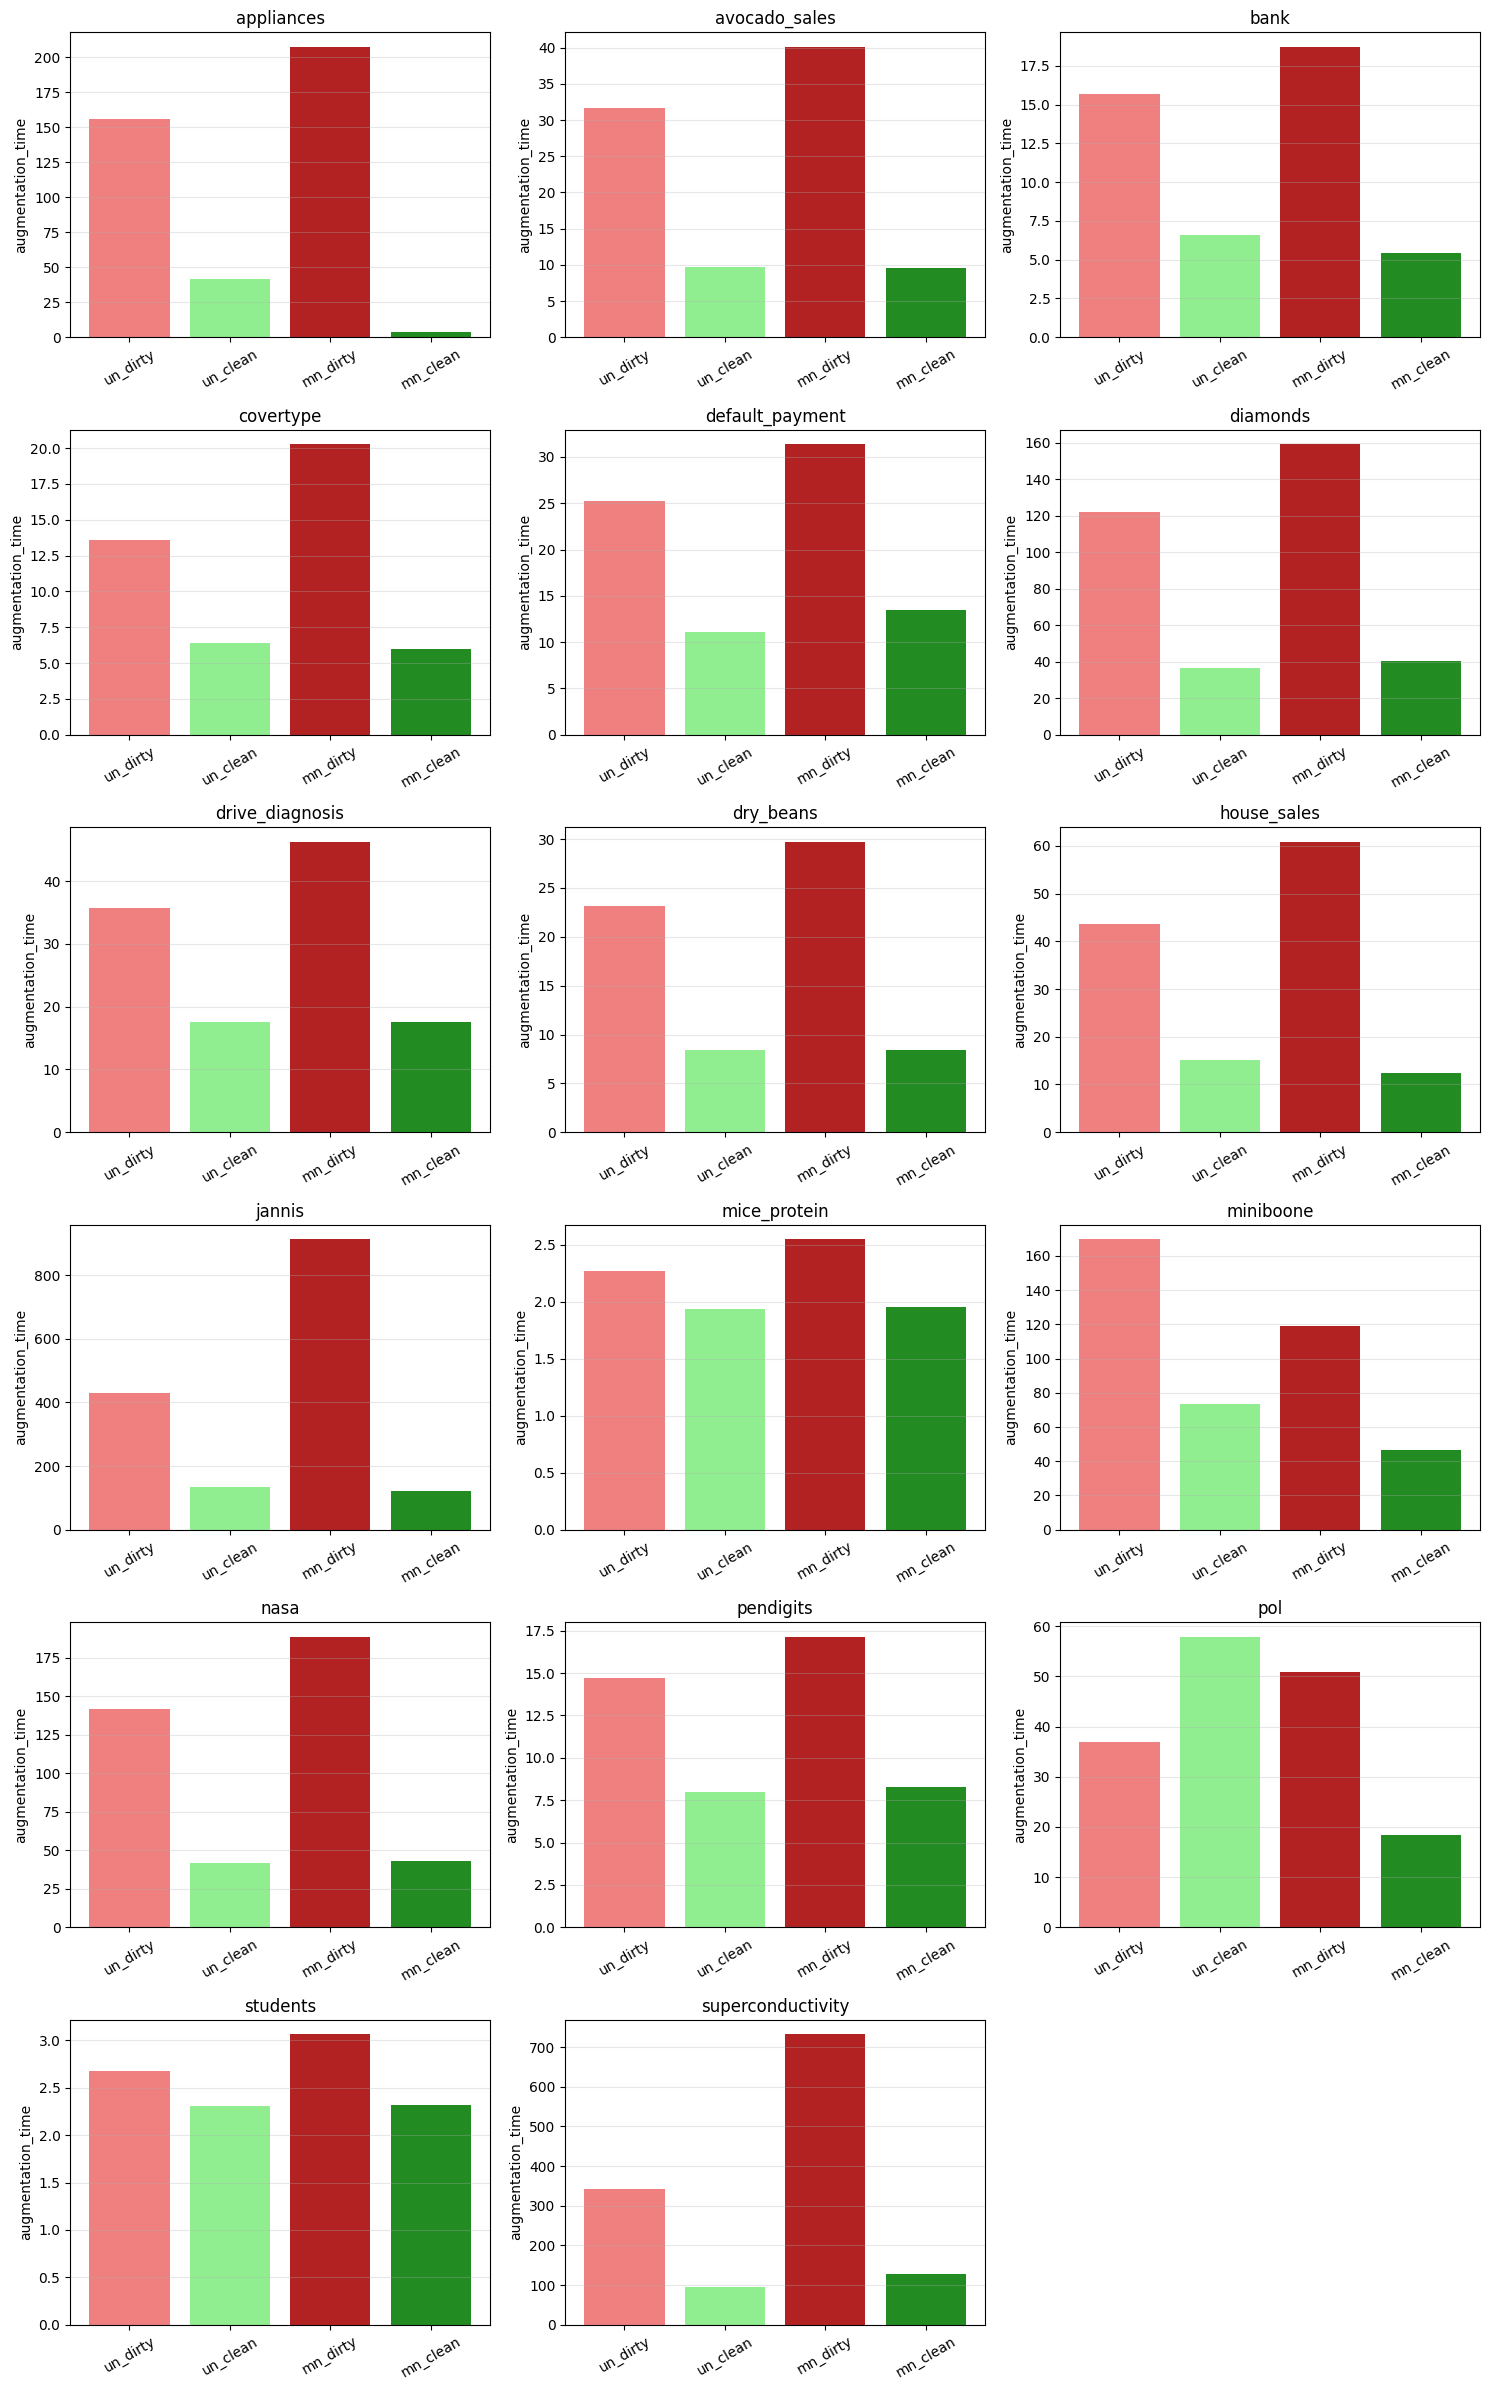

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

# =========================
# Load data
# =========================

df = pd.read_csv("results_final_classification_2.csv")[["benchmark", "augmentation_time"]]
df_reg = pd.read_csv("results_final_regression_2.csv")[["benchmark", "augmentation_time"]]
df = pd.concat([df, df_reg]).drop_duplicates().reset_index(drop=True)

# =========================
# Helper functions
# =========================

def get_base_benchmark(name):

    suffixes = [
        "_un_dirty",
        "_un_clean",
        "_mn_dirty",
        "_mn_clean",
    ]

    for s in suffixes:
        if name.endswith(s):
            return name[:-len(s)]

    return name


# =========================
# Benchmark groups
# =========================

all_benchmarks = df["benchmark"].unique()
base_benchmarks = sorted(set(get_base_benchmark(b) for b in all_benchmarks))

# =========================
# Variants
# =========================

variants = {
    # "normal": {
    #     "suffix": "",
    #     "color": "grey",
    #     "label": "base",
    # },

    # 1CF -> lighter colors
    "noisy_1cf": {
        "suffix": "_un_dirty",
        "color": "lightcoral",
        "label": "un_dirty",
    },
    "cleaned_1cf": {
        "suffix": "_un_clean",
        "color": "lightgreen",
        "label": "un_clean",
    },

    # 2CF -> darker colors
    "noisy_2cf": {
        "suffix": "_mn_dirty",
        "color": "firebrick",
        "label": "mn_dirty",
    },
    "cleaned_2cf": {
        "suffix": "_mn_clean",
        "color": "forestgreen",
        "label": "mn_clean",
    },
}

# =========================
# Mosaic layout
# =========================

n_benchmarks = len(base_benchmarks)

ncols = 3
nrows = math.ceil(n_benchmarks / ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5 * ncols, 4 * nrows),
)

axes = np.array(axes).reshape(nrows, ncols)

# =========================
# Plot barplots
# =========================

bar_width = 0.15

for idx, base in enumerate(base_benchmarks):

    row = idx // ncols
    col = idx % ncols

    ax = axes[row, col]

    means = []
    colors = []
    labels = []

    for _, cfg in variants.items():

        benchmark_name = base + cfg["suffix"]

        subset = df[df["benchmark"] == benchmark_name]

        if subset.empty:
            continue

        mean_time = subset["augmentation_time"].mean()

        means.append(mean_time)
        colors.append(cfg["color"])
        labels.append(cfg["label"])

    x = np.arange(len(means))

    ax.bar(
        x,
        means,
        color=colors,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30)
    ax.set_title(base)

    ax.set_ylabel("augmentation_time")
    ax.grid(True, axis="y", alpha=0.3)

# =========================
# Remove empty axes
# =========================

total_slots = nrows * ncols

for empty_idx in range(n_benchmarks, total_slots):

    row = empty_idx // ncols
    col = empty_idx % ncols

    fig.delaxes(axes[row, col])

# =========================
# Final layout
# =========================

plt.tight_layout()
plt.show()